<div align="center">
#Project-2
# 🛡️ Supervised Learning Fraud Detection Pipeline

## 📊 Dataset: Credit Card Fraud Detection

</div>

The **Credit Card Fraud Detection** dataset was selected for this project because it contains real-world credit card transactions with both genuine and fraudulent cases, making it suitable for building and evaluating a fraud detection model.

This project aims to develop a supervised machine learning pipeline to identify fraudulent transactions. The workflow includes handling class imbalance using **SMOTE (Synthetic Minority Over-sampling Technique)**, training **Logistic Regression** and **Random Forest** classification models, and evaluating their performance using **Precision**, **Recall**, and **ROC-AUC** metrics instead of relying solely on accuracy, as required by the DecodeLabs project.

In [1]:
!ls

sample_data


In [3]:
from google.colab import files
uploaded = files.upload()

Saving creditcard[1].csv to creditcard[1].csv


In [4]:
!ls

'creditcard[1].csv'   sample_data


✅ **Step 1: Import Required Libraries**

In [5]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


✅** Step 2: Load the Dataset**

In [7]:
# Load Dataset

df = pd.read_csv("creditcard[1].csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


✅ **Step 3: Display the First Five Rows**

In [8]:
# Display first five rows

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Step 4: Understanding the Dataset**

<div align="center">

# 📊 Step 4: Understanding the Dataset

</div>

In this step, the dataset is examined to understand its dimensions, data types, statistical summary, missing values, duplicate records, and class distribution. This analysis helps identify data quality issues before preprocessing and model training.

In [9]:
# Shape of the Dataset

print("Number of Rows and Columns:", df.shape)

Number of Rows and Columns: (284807, 31)


In [10]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
# Statistical Summary

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [12]:
# Missing Values

df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [13]:
# Duplicate Records

print("Number of Duplicate Records:", df.duplicated().sum())

Number of Duplicate Records: 1081


In [14]:
# Class Distribution

df['Class'].value_counts()

,count
Class,
0,284315
1,492


<div align="center">

# 📊 Step 5: Data Visualization

</div>

In this step, the dataset is visualized to understand the distribution of fraudulent and non-fraudulent transactions, transaction amounts, and feature relationships. These visualizations provide valuable insights before building machine learning models.

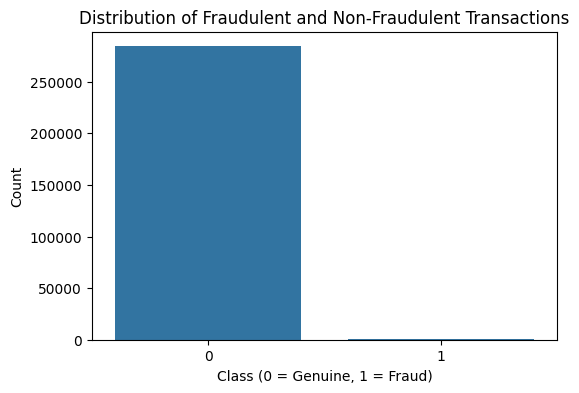

In [15]:
# Visualize Class Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Distribution of Fraudulent and Non-Fraudulent Transactions")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

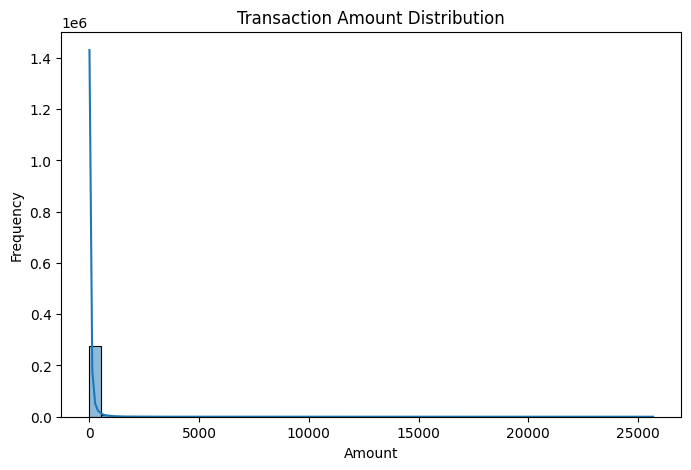

In [16]:
# Transaction Amount Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

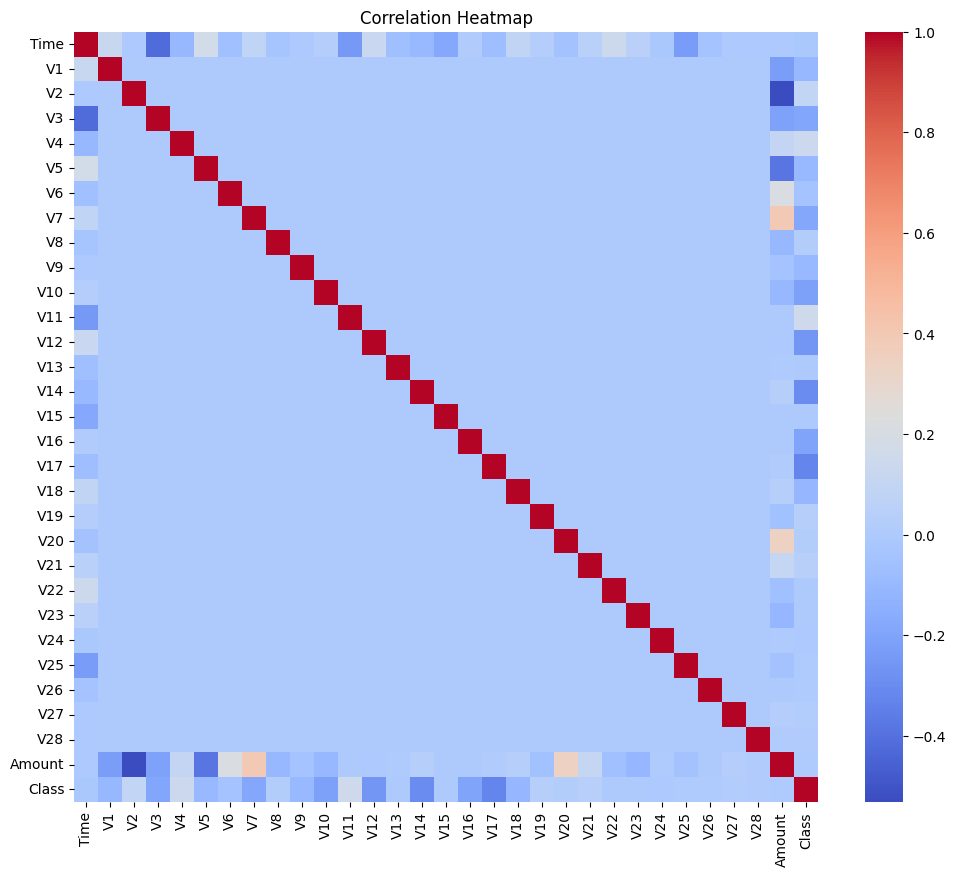

In [17]:
# Correlation Heatmap

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

<div align="center">

# ⚙️ Step 6: Data Preprocessing

</div>

Data preprocessing is performed to prepare the dataset for machine learning. In this step, the features and target variable are separated, the data is split into training and testing sets, numerical features are standardized, and SMOTE is applied to balance the highly imbalanced classes before model training.

In [19]:
# Separate Features and Target

X = df.drop('Class', axis=1)
y = df['Class']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (284807, 30)
Target Shape: (284807,)


In [20]:
# Split the Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (227845, 30)
Testing Set: (56962, 30)


In [21]:
# Standardize the Amount Feature

scaler = StandardScaler()

X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [22]:
# Apply SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original Training Dataset Shape:", y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Original Training Dataset Shape: Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


<div align="center">

# 🤖 Step 7: Logistic Regression Model

</div>

In this step, a Logistic Regression model is trained using the balanced training dataset obtained after applying SMOTE. The trained model is then used to predict fraudulent and genuine transactions on the test dataset.

In [23]:
# Train Logistic Regression Model

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_smote, y_train_smote)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [24]:
# Predict on Test Data

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("Predictions Generated Successfully!")

Predictions Generated Successfully!


In [25]:
# Evaluate Logistic Regression Model

print("Precision :", precision_score(y_test, y_pred_lr))
print("Recall    :", recall_score(y_test, y_pred_lr))
print("F1-Score  :", f1_score(y_test, y_pred_lr))
print("ROC-AUC   :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Precision : 0.08127853881278539
Recall    : 0.9081632653061225
F1-Score  : 0.14920368818105617
ROC-AUC   : 0.9749491805726229

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.08      0.91      0.15        98

    accuracy                           0.98     56962
   macro avg       0.54      0.95      0.57     56962
weighted avg       1.00      0.98      0.99     56962



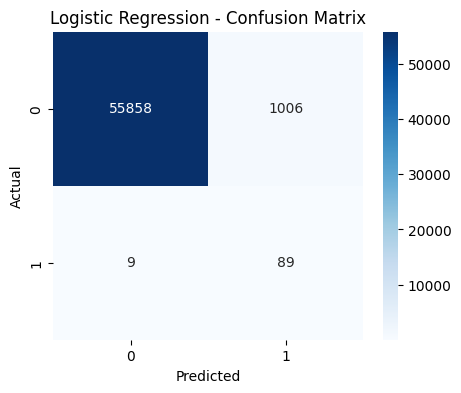

In [26]:
# Confusion Matrix

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<div align="center">

# 🌲 Step 8: Random Forest Model

</div>

In this step, a Random Forest classifier is trained using the balanced training dataset generated through SMOTE. The model is then used to predict fraudulent and genuine transactions on the test dataset. Its performance is evaluated using Precision, Recall, F1-Score, ROC-AUC, and a Confusion Matrix, as required for fraud detection on an imbalanced dataset.

In [34]:
# Train Random Forest Model (Faster Version)

rf_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [33]:
print(X_train_smote.shape)

(454902, 30)


In [35]:
# Predict on Test Data

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Predictions Generated Successfully!")

Predictions Generated Successfully!


In [36]:
# Evaluate Random Forest Model

print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall    :", recall_score(y_test, y_pred_rf))
print("F1-Score  :", f1_score(y_test, y_pred_rf))
print("ROC-AUC   :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Precision : 0.14100486223662884
Recall    : 0.8877551020408163
F1-Score  : 0.24335664335664337
ROC-AUC   : 0.9709387166515453

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.14      0.89      0.24        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.62     56962
weighted avg       1.00      0.99      0.99     56962



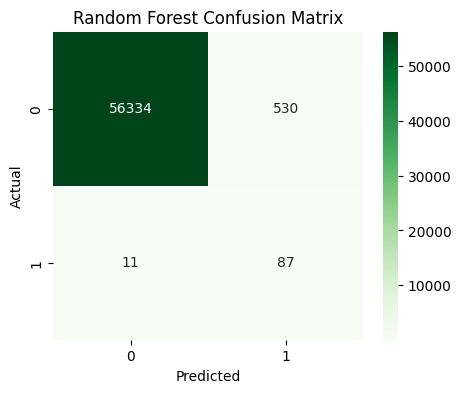

In [37]:
# Confusion Matrix

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

✅ **Step 9: Model Comparison**

<div align="center">

# 📊 Step 9: Model Comparison

</div>

The performance of Logistic Regression and Random Forest is compared using Precision, Recall, F1-Score, and ROC-AUC. These metrics are more suitable than accuracy for evaluating highly imbalanced fraud detection datasets.

In [38]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.081279,0.908163,0.149204,0.974949
1,Random Forest,0.141005,0.887755,0.243357,0.970939


**Step 10: Best Visual Model Comparison (Graph)**

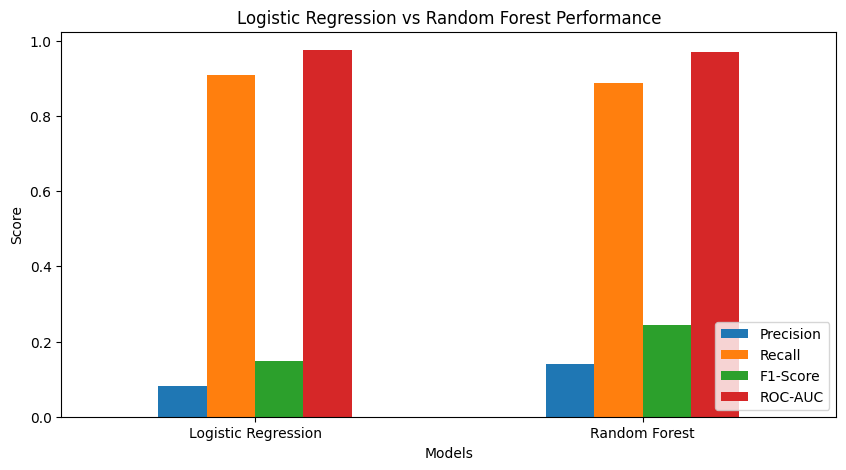

In [39]:
import matplotlib.pyplot as plt

metrics = ["Precision", "Recall", "F1-Score", "ROC-AUC"]

comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Logistic Regression vs Random Forest Performance")
plt.ylabel("Score")
plt.xlabel("Models")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

**Step 11: Final Model Selection**

Final Model Selection:

Based on the comparison results, Random Forest is selected as the final model. It achieved higher Precision and F1-score compared to Logistic Regression, making it more suitable for fraud detection. Although Logistic Regression achieved slightly higher Recall and ROC-AUC, Random Forest provides a better balance between identifying fraud cases and reducing false positives.

**Step 12:  To Save the Final Random Forest Model**

In [40]:
import joblib

# Saving the trained Random Forest model
joblib.dump(rf_model, "fraud_detection_random_forest.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [41]:
!ls

'creditcard[1].csv'   fraud_detection_random_forest.pkl   sample_data


## Conclusion
In this project, a supervised learning fraud detection pipeline was developed to identify fraudulent transactions.

Two machine learning models, Logistic Regression and Random Forest, were trained and evaluated using Precision, Recall, F1-score, and ROC-AUC metrics.

The model comparison showed that Random Forest achieved better Precision and F1-score, making it the preferred model for fraud detection. The final Random Forest model was saved for future prediction purposes.

This project demonstrates the complete machine learning workflow including data preprocessing, handling class imbalance, model training, evaluation, comparison, and model saving.